# Классификация

# Сравнение фильтров (границ) изображений

In [ ]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import cv2

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [ ]:
import os
from google.colab import files

# Создаём папку и загружаем файлы
os.makedirs("data1", exist_ok=True)
uploaded = files.upload()

# Перемещаем в data
for name in uploaded.keys():
    os.rename(name, f"data1/{name}")

# Проверяем
print(os.listdir("data1"))

Saving cat_1.jpg to cat_1.jpg
Saving cat_2.jpg to cat_2.jpg
Saving cat_3.jpg to cat_3.jpg
Saving cat_4.jpg to cat_4.jpg
Saving cat_5.JPG to cat_5.JPG
Saving cat_6.JPG to cat_6.JPG
Saving cat_7.JPG to cat_7.JPG
Saving cat_8.JPG to cat_8.JPG
Saving dog_1.jpg to dog_1.jpg
Saving dog_2.jpg to dog_2.jpg
Saving dog_3.jpg to dog_3.jpg
Saving dog_4.jpg to dog_4.jpg
Saving dog_5.JPG to dog_5.JPG
Saving dog_6.JPG to dog_6.JPG
Saving dog_7.JPG to dog_7.JPG
['cat_2.jpg', 'dog_5.JPG', 'cat_1.jpg', 'dog_6.JPG', 'dog_1.jpg', 'dog_3.jpg', 'dog_2.jpg', 'cat_4.jpg', 'cat_7.JPG', 'dog_4.jpg', 'cat_6.JPG', 'dog_7.JPG', 'cat_5.JPG', 'cat_3.jpg', 'cat_8.JPG']


In [ ]:
files = os.listdir("data1")
images = [cv2.imread(f"data1/{file}") for file in files]
lendata = len(images)

In [ ]:
files

['cat_2.jpg',
 'dog_5.JPG',
 'cat_1.jpg',
 'dog_6.JPG',
 'dog_1.jpg',
 'dog_3.jpg',
 'dog_2.jpg',
 'cat_4.jpg',
 'cat_7.JPG',
 'dog_4.jpg',
 'cat_6.JPG',
 'dog_7.JPG',
 'cat_5.JPG',
 'cat_3.jpg',
 'cat_8.JPG']

In [ ]:
y = []   # принадлежность классу
for i in range(len(images)):
    if files[i].startswith("cat"):
        y.append(1)
    else:
        y.append(0)
y

[1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1]

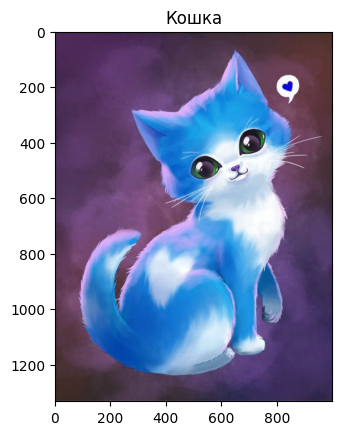

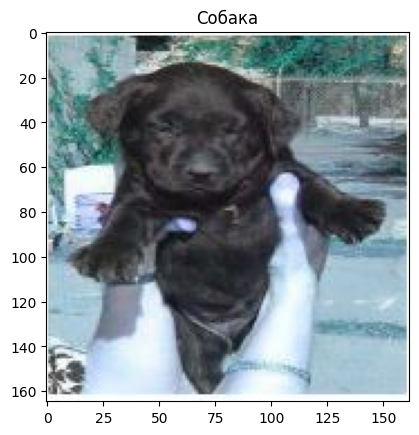

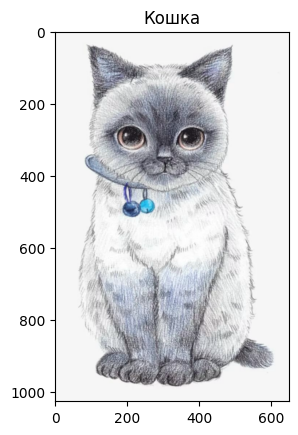

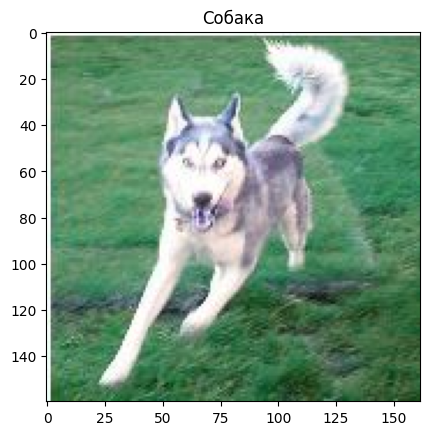

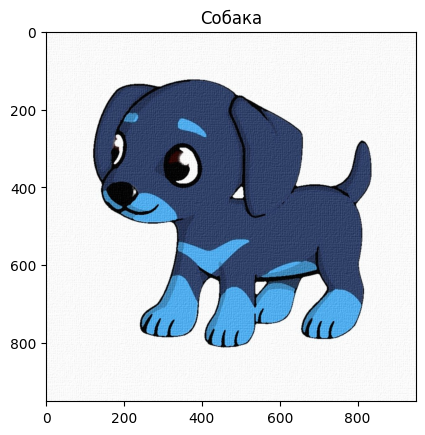

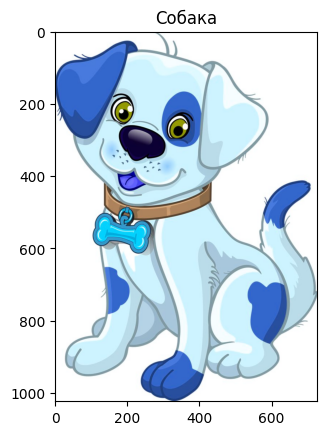

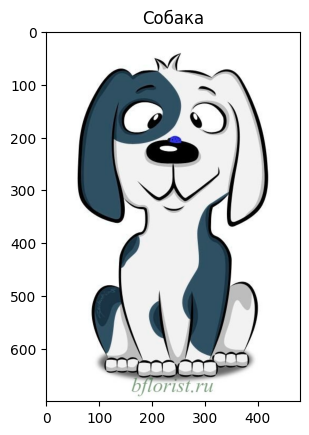

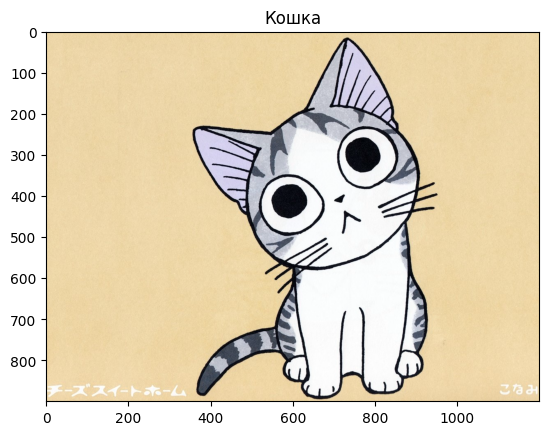

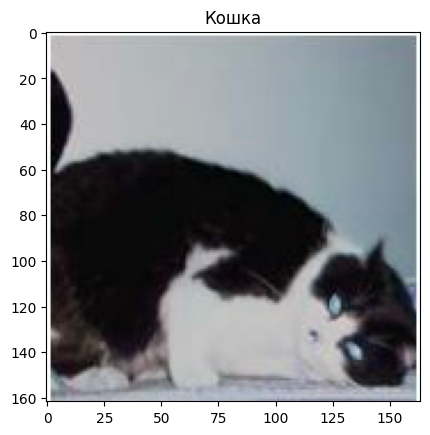

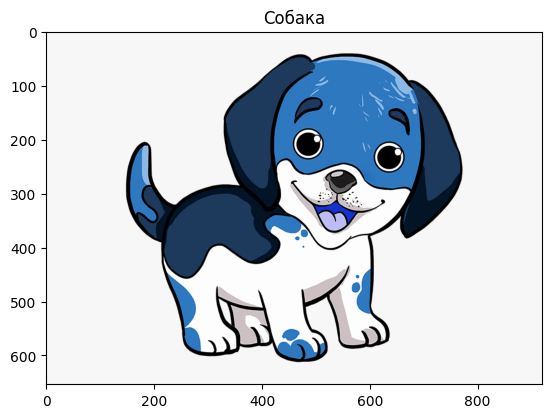

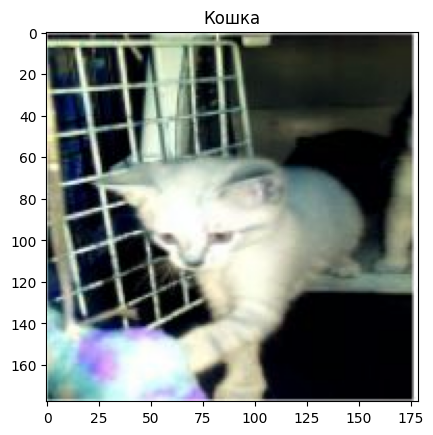

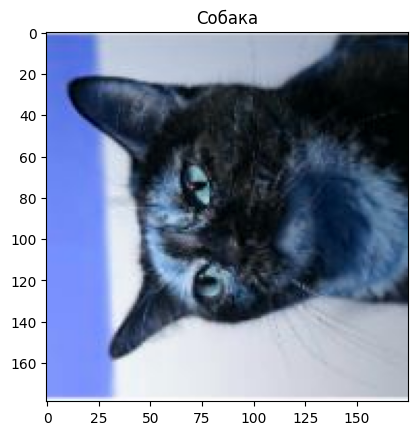

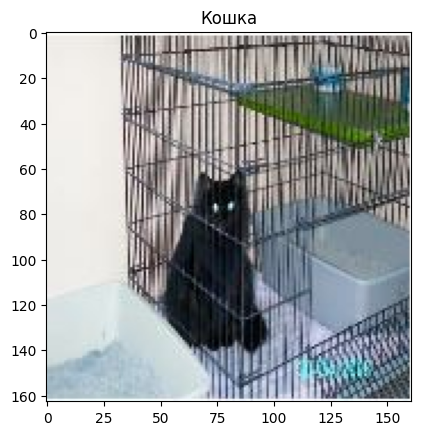

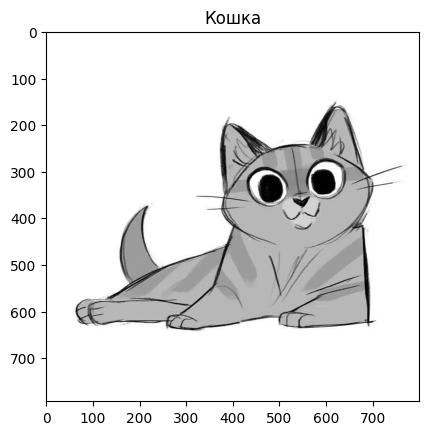

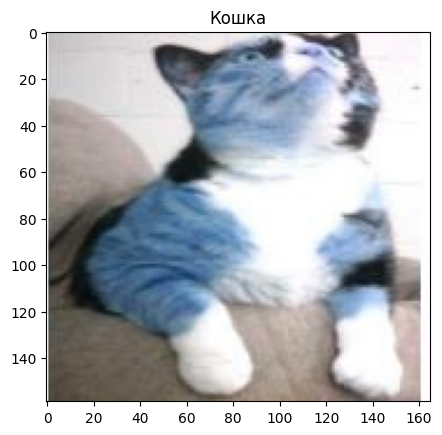

In [ ]:
for i in range(len(images)):
    plt.imshow(images[i])
    plt.title("Кошка" if files[i].startswith("cat") else "Собака")
    plt.show()

- Каждое изображение надо отмасштабировать и привести к чёрно-белым оттенкам

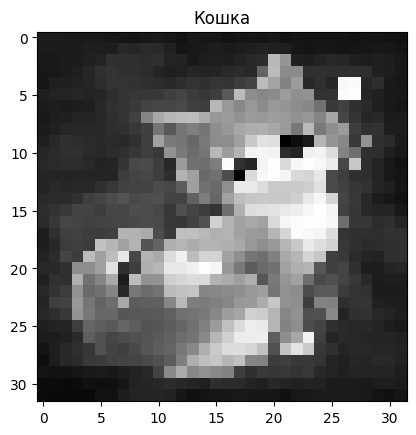

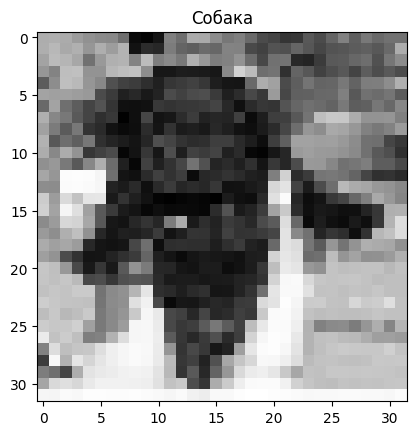

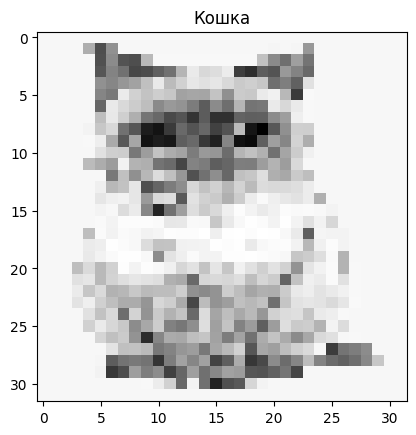

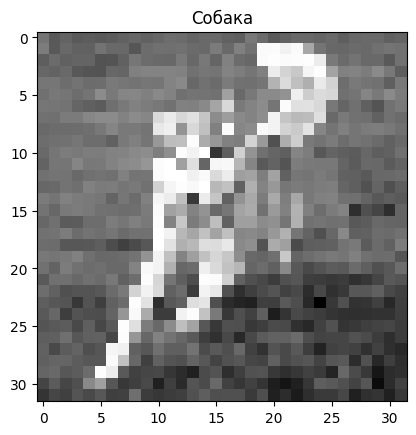

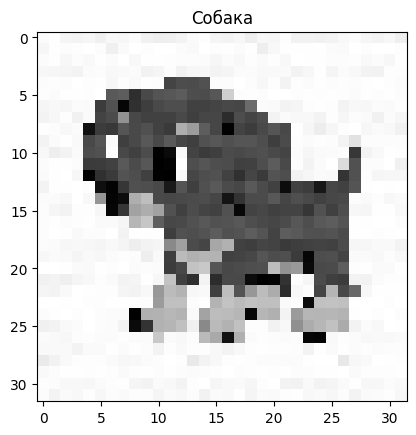

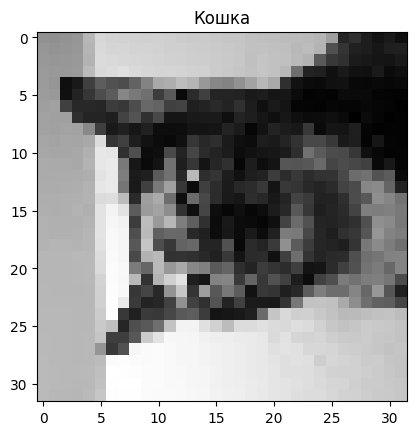

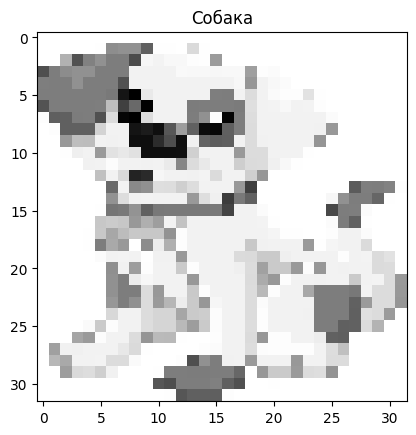

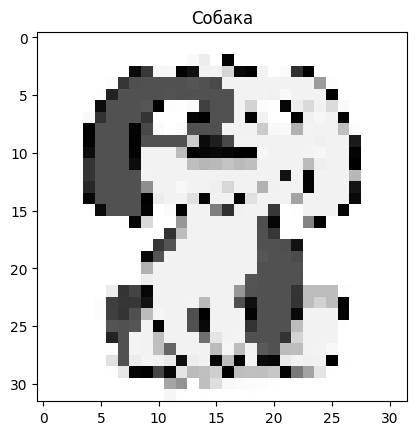

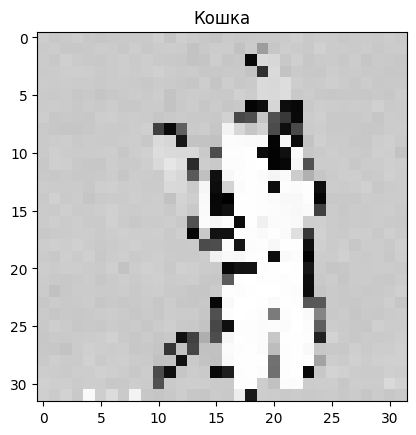

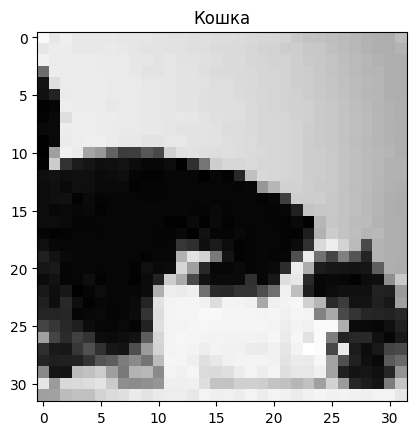

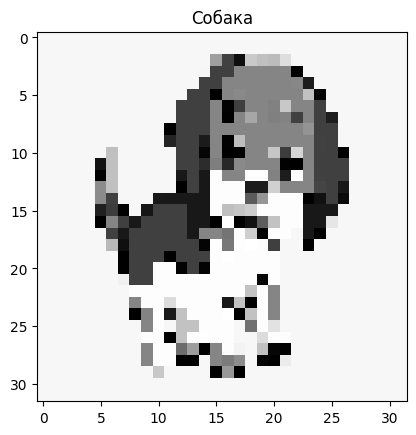

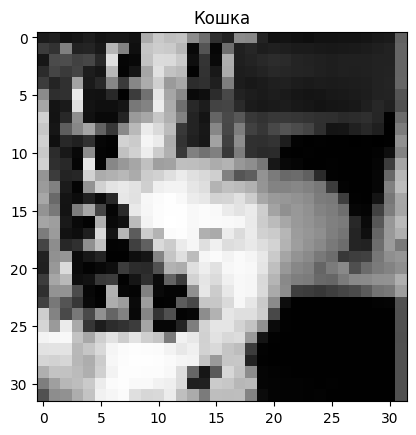

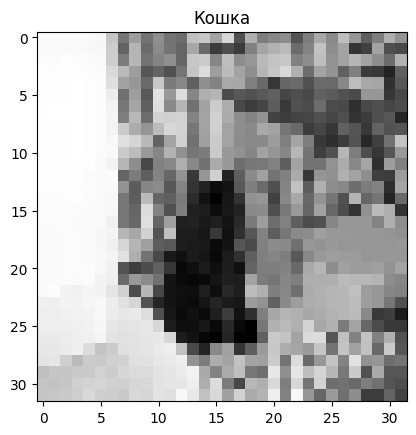

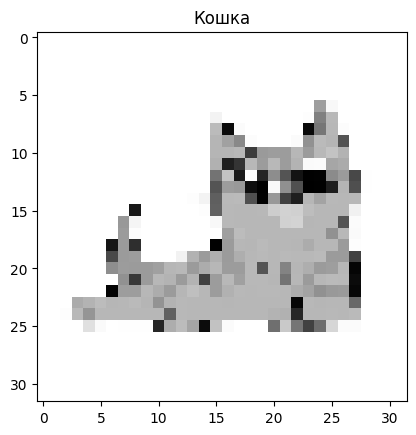

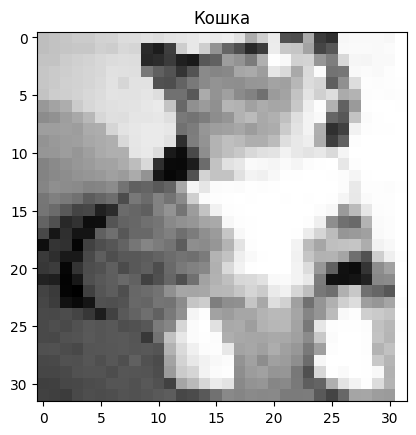

In [ ]:
resized = [cv2.resize(cv2.cvtColor(image, cv2.COLOR_BGR2GRAY), (32, 32)) for image in images]

for i in range(len(resized)):
    plt.imshow(resized[i], cmap=plt.cm.gray)
    plt.title("Кошка" if files[i].startswith("cat") else "Собака")
    plt.show()

- Теперь последовательно пробуем применить **фильтр**, а затем обучить модель логистической регрессии для предсказания класса.

## Дискретный оператор Лапласа

Составляем набор данных

 ksize=3  размер ядра

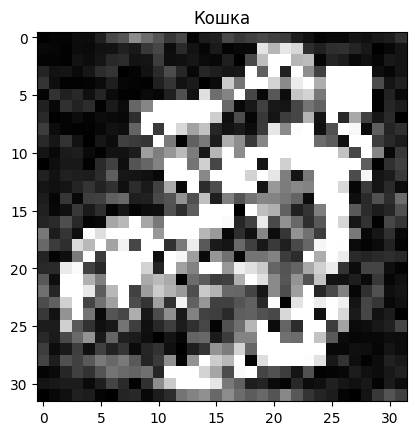

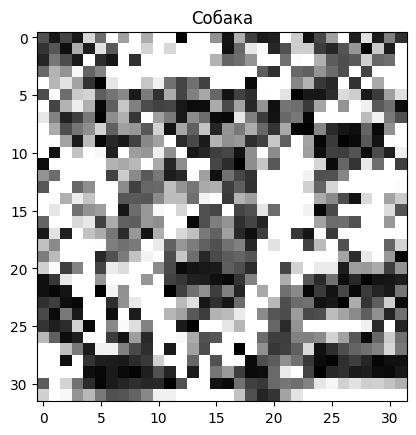

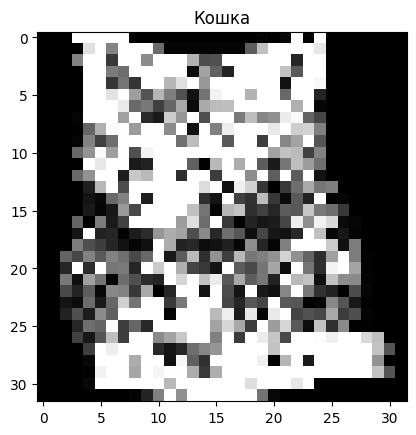

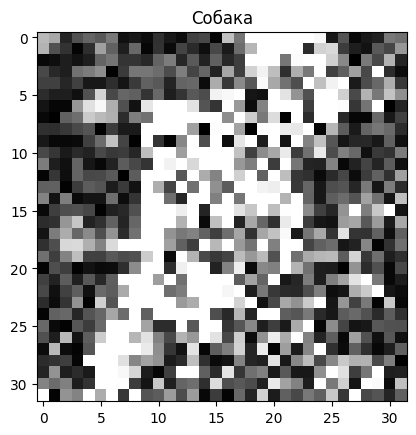

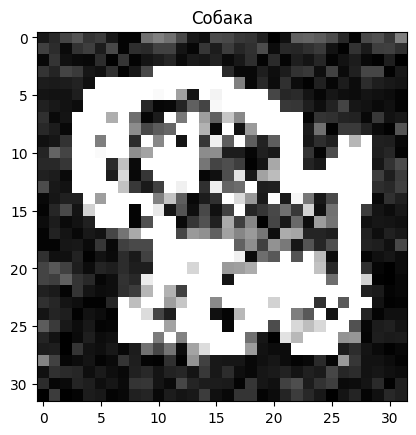

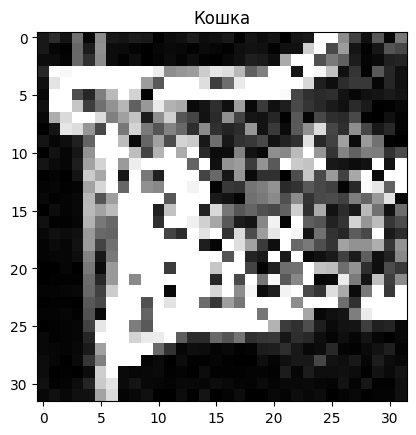

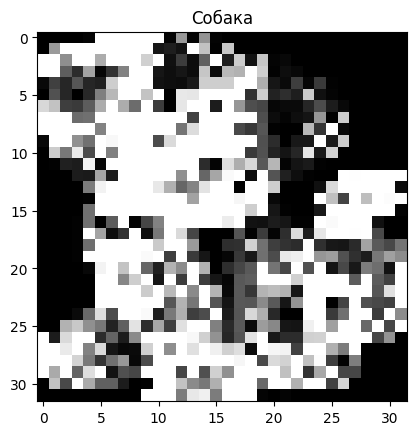

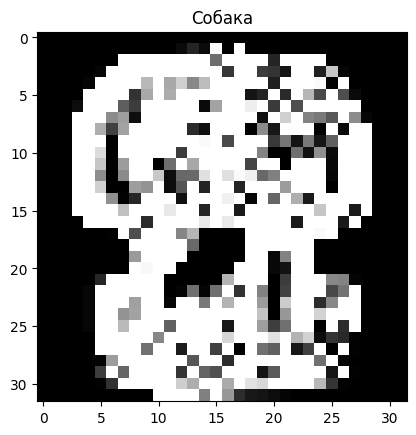

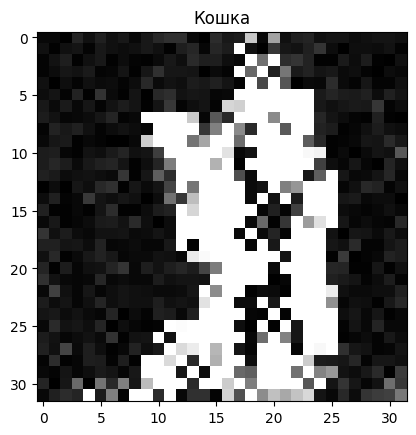

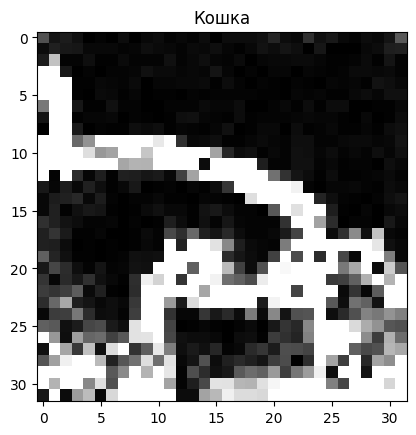

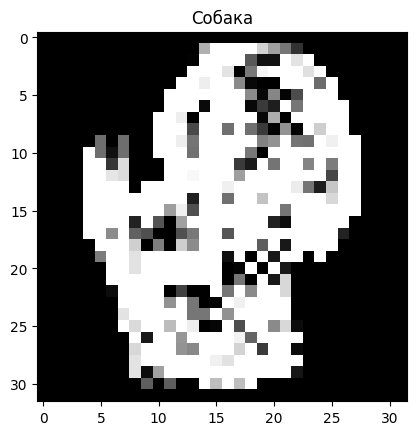

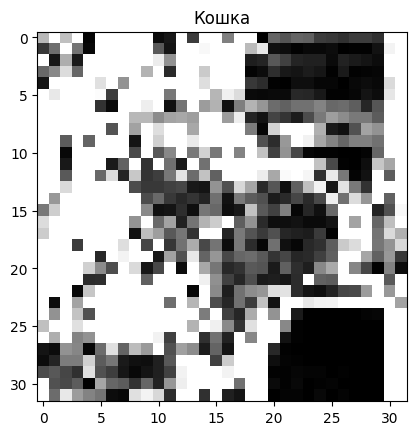

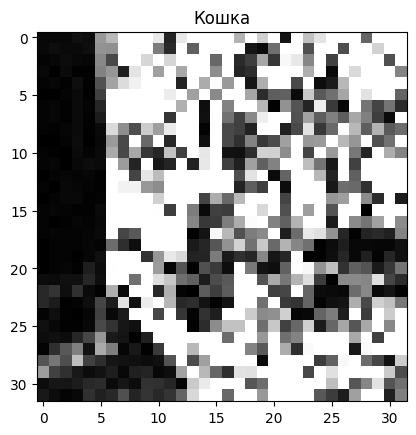

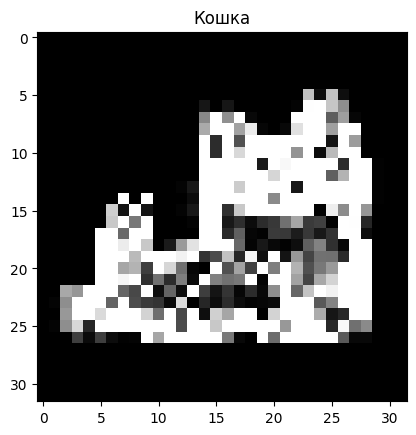

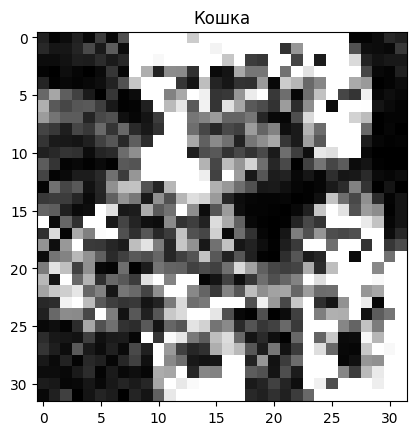

In [ ]:
laplacian_data = [cv2.convertScaleAbs(cv2.Laplacian(image, cv2.CV_16S, ksize=3)) for image in resized]

for i in range(len(laplacian_data)):
    plt.imshow(laplacian_data[i], cmap=plt.cm.gray)
    plt.title("Кошка" if files[i].startswith("cat") else "Собака")
    plt.show()

Составляем матрицу объектов-признаков и целевую переменную

In [ ]:
X = np.float32(laplacian_data).reshape(lendata, -1)
y

[1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1]

In [ ]:
X

array([[  0.,   4.,   4., ...,  56.,  84.,  64.],
       [ 80.,  24.,  68., ..., 255., 255., 255.],
       [  0.,   0.,   0., ...,   0.,   0.,   0.],
       ...,
       [  8.,   8.,   8., ..., 255.,  32., 128.],
       [  0.,   0.,   0., ...,   0.,   0.,   0.],
       [ 32.,   4.,  12., ..., 255., 255., 255.]], dtype=float32)

In [ ]:
X.shape

(15, 1024)

In [ ]:
model = make_pipeline(
    StandardScaler(),
    LogisticRegression()
)

model.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression())])

Оцениваем качество как долю правильных ответов

In [ ]:
model.score(X, y)

1.0

## Детектор границ Канни

cv2.Canny(img, 50, 150)                              # threshold1, threshold2

threshold1	низкий	Слабые границы

threshold2	высокий	Сильные границы


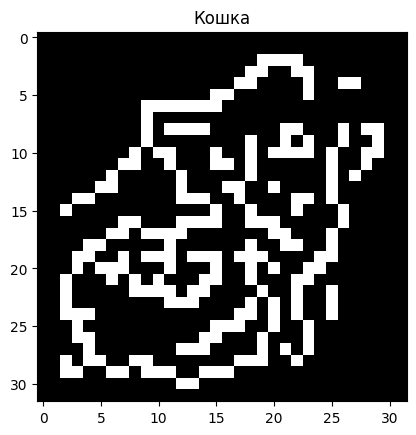

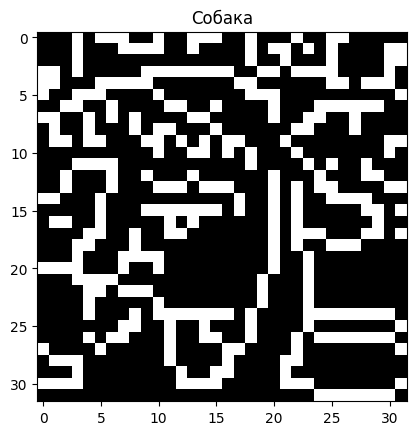

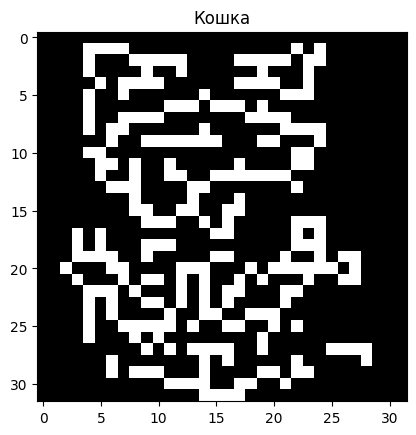

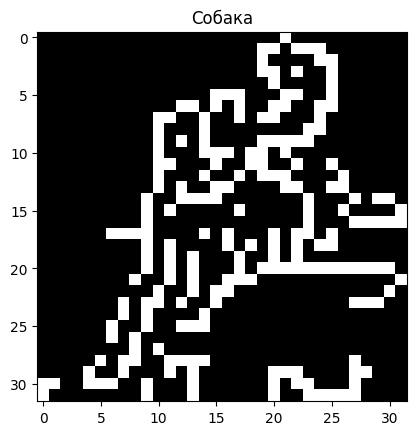

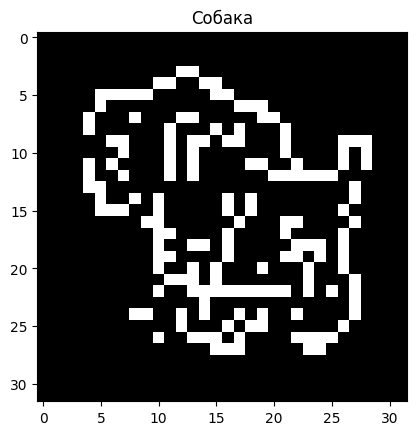

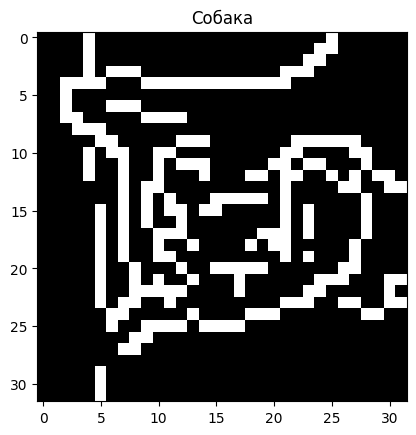

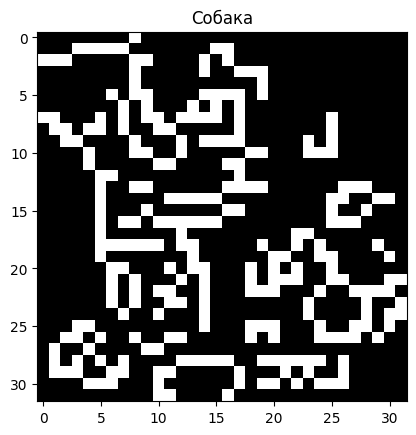

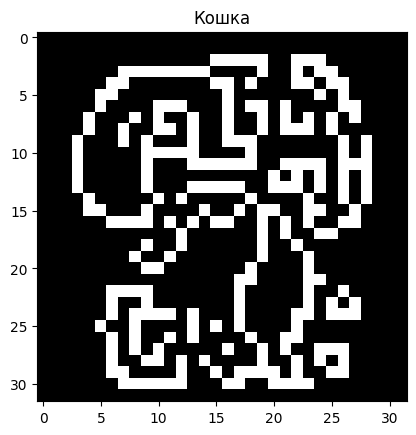

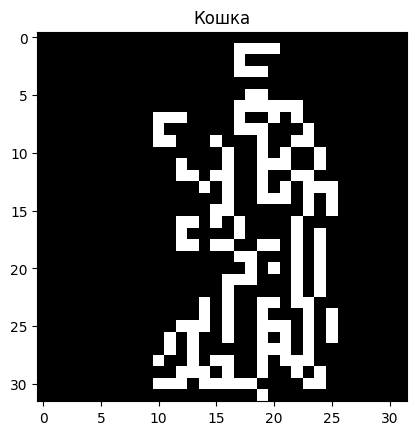

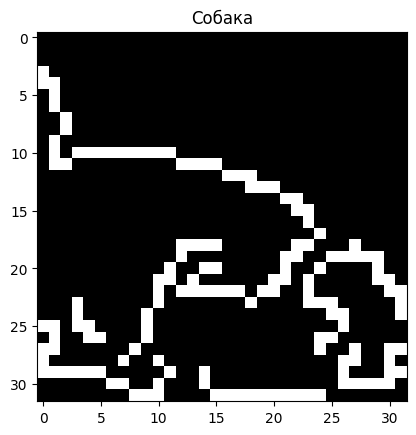

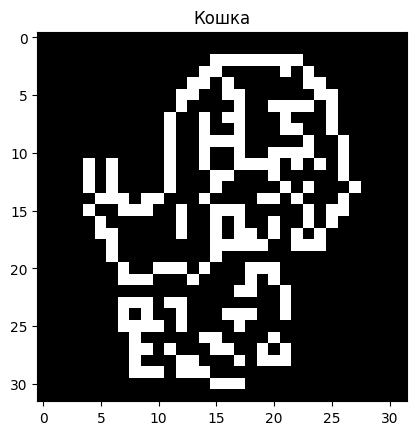

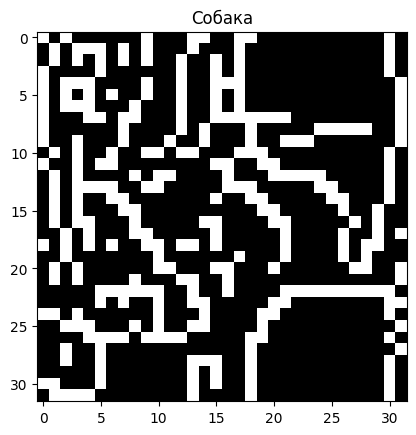

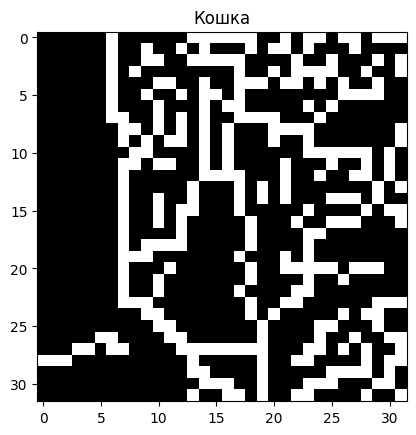

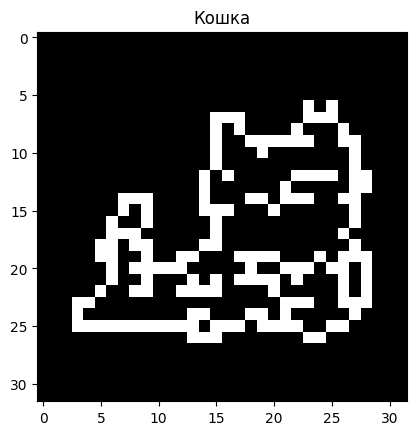

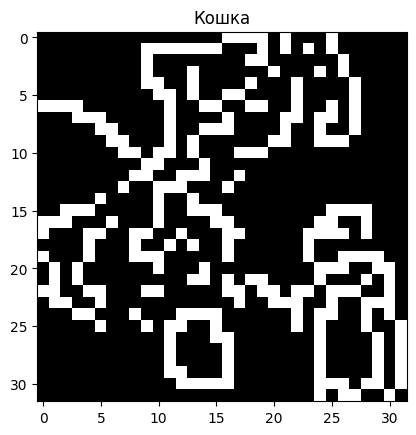

In [ ]:
canny_data = [cv2.convertScaleAbs(cv2.Canny(image, 100, 200)) for image in resized]

for i in range(len(canny_data)):
    plt.imshow(canny_data[i], cmap=plt.cm.gray)
    plt.title("Кошка" if files[i].startswith("cat") else "Собака")
    plt.show()

Составляем матрицу объектов-признаков

In [ ]:
X = np.float32(canny_data).reshape(lendata, -1)

Обучаем модель

In [ ]:
model = make_pipeline(
    StandardScaler(),
    LogisticRegression()
)

model.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression())])

Оцениваем качество как долю правильных ответов

In [ ]:
model.score(X, y)

1.0

## Оператор Собеля

Sobel X (1,0)	Вертикальные границы	┃

Sobel Y (0,1)	Горизонтальные границы	━

Combined	Все границы	┼


In [92]:
sobel_data = []

for image in resized:
    sobx = cv2.Sobel(image, cv2.CV_16S, dx=1, dy=0)
    soby = cv2.Sobel(image, cv2.CV_16S, dx=0, dy=1)
    grad = cv2.Sobel(image, cv2.CV_16S, dx=1, dy=1)

    absX = cv2.convertScaleAbs(sobx)
    absY = cv2.convertScaleAbs(soby)
    absgrad = cv2.addWeighted(absX, .5, absY, .5, 0)

    sobel_data.append(absgrad)

Рисуем картинки

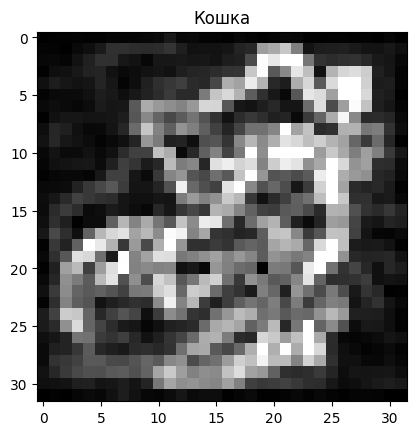

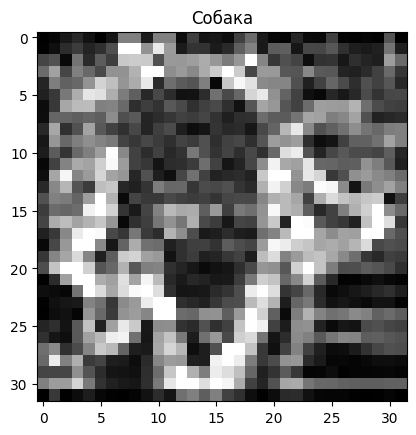

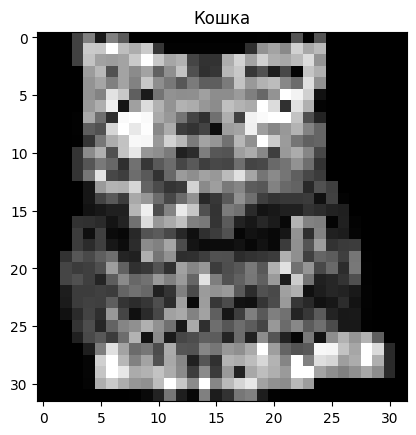

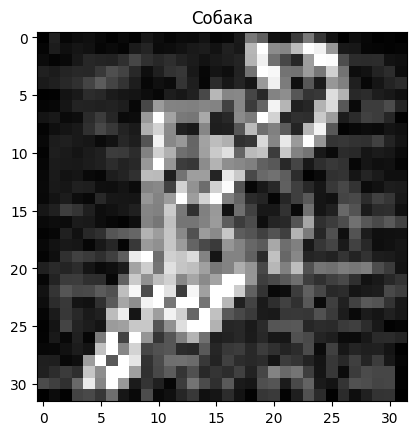

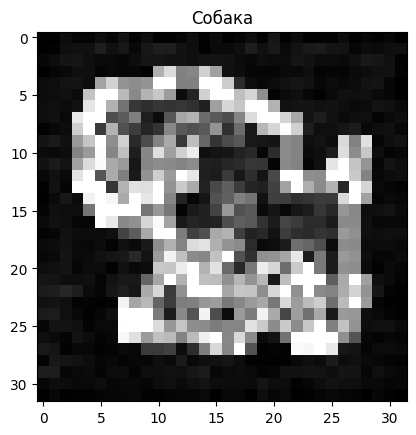

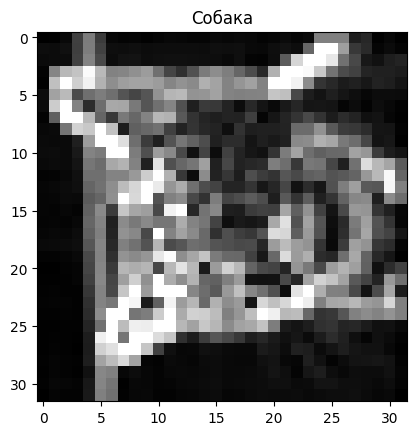

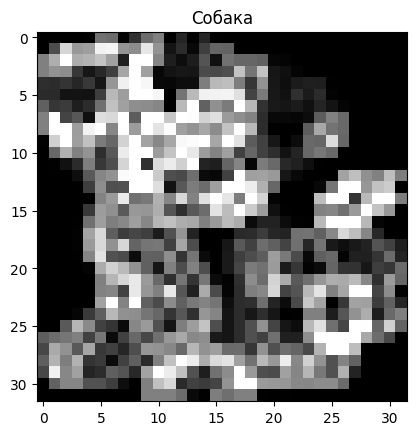

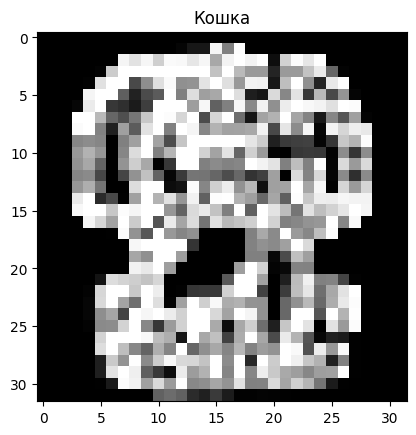

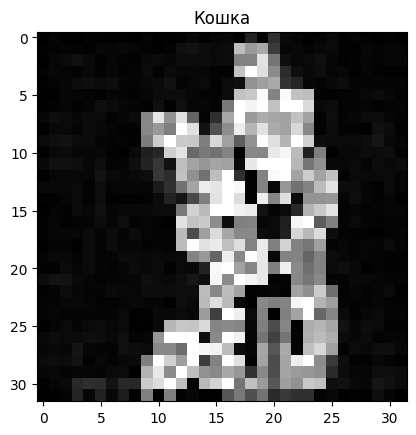

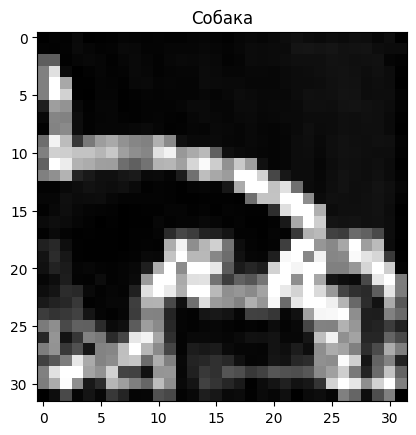

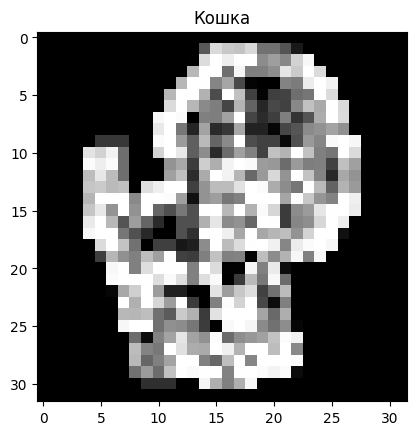

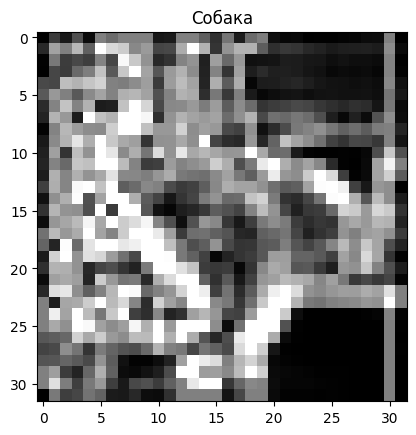

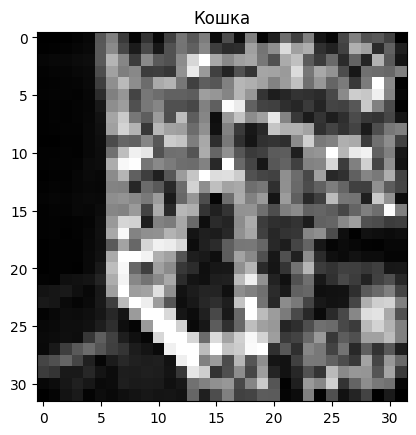

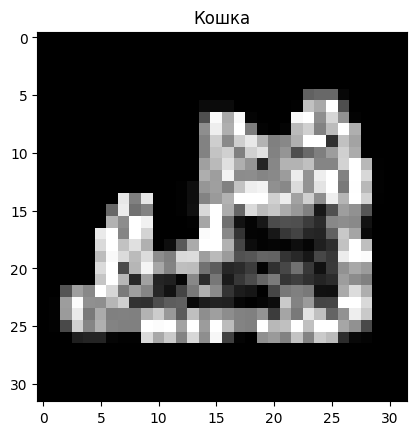

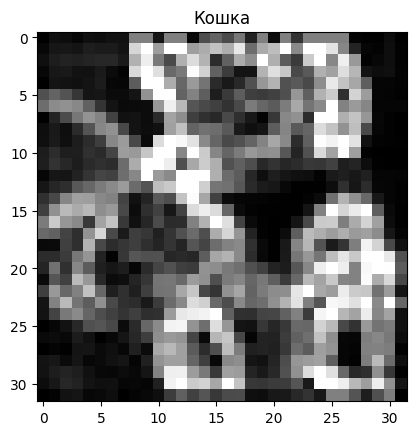

In [ ]:
for i in range(len(sobel_data)):
    plt.imshow(sobel_data[i], cmap=plt.cm.gray)
    plt.title("Кошка" if files[i].startswith("cat") else "Собака")
    plt.show()

Составляем матрицу объектов-признаков

In [ ]:
X = np.float32(sobel_data).reshape(lendata, -1)

Обучаем модель

In [ ]:
model = make_pipeline(
    StandardScaler(),
    LogisticRegression()
)

model.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression())])

Оцениваем качество как долю правильных ответов

In [ ]:
model.score(X, y)

1.0

**Вывод:** все три фильтра показали одинаково хороший результат

In [ ]:
X = np.float32(sobel_data).reshape(lendata, -1)

In [ ]:
model = make_pipeline(StandardScaler(), RandomForestClassifier())

model.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('randomforestclassifier', RandomForestClassifier())])

In [ ]:
model.score(X, y)

1.0